In [4]:
from langchain_community.document_loaders import PyPDFLoader

In [9]:
import os
print(os.getcwd()) # 현재 위치 출력

c:\Users\Admin\hipython\llm\02_langchain_proj


In [25]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [10]:
loader = PyPDFLoader("../data/Samsung_Card_Manual_Korean_1.3.pdf")
pages = loader.load()  # List[Document] 형태로 반환

In [11]:
len(pages)

6

In [12]:
pages[0].page_content[:100]
pages[0].metadata

{'producer': 'Microsoft® Word 2010',
 'creator': 'Microsoft® Word 2010',
 'creationdate': '2019-01-02T09:40:06+09:00',
 'author': 'master',
 'moddate': '2019-01-02T09:40:06+09:00',
 'source': '../data/Samsung_Card_Manual_Korean_1.3.pdf',
 'total_pages': 6,
 'page': 0,
 'page_label': '1'}

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [16]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = splitter.split_documents(pages)

In [17]:
docs

[Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2019-01-02T09:40:06+09:00', 'author': 'master', 'moddate': '2019-01-02T09:40:06+09:00', 'source': '../data/Samsung_Card_Manual_Korean_1.3.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n1 \n \n \n \n \n \n \n \n \n \n \n \n \n \n. \n \n법적 고지 사항 \n삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  \n여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 \n어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 \n유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 \n지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. \n삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적'),
 Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2019-01-02T09:40:06+09:00', 'author': 'master', 'moddate': '2019-01-02T09:40:06+09:00', 'source': '../d

In [19]:
print(docs[0].page_content)

사용설명서           SAMSUNG PROPRIETARY 
Revision1.3 
1 
 
 
 
 
 
 
 
 
 
 
 
 
 
. 
 
법적 고지 사항 
삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  
여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 
어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 
유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 
지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. 
삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적


In [20]:
print(docs[1].page_content)

삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적 
상해를 야기할 수 있는 유사 제품, 군용 또는 방어 기기 또는 특정 계약/조항이 적용될 수 있는 정부의 조달에 
사용할 의도로 설계되지 않았습니다. 삼성 제품에 관한 업데이트 또는 추가 정보는 가까운 삼성 대리점에 
문의하십시오. 모든 브랜드 이름, 상표 및 등록 상표는 해당 소유권자가 소유합니다.  
Copyright, 2019 Samsung Electronics Co., Ltd. All rights reserved.  
 
COPYRIGHT 2019  
본 자료의 저작권은 삼성 전자에 있습니다. 본 자료의 전부 또는 일부를 무단으로 복제하거나 사용 또는 공개하는 
행위는 엄격히 금지되며 저작권법에 위배됩니다. 
상표 및 서비스 표시


In [26]:
from langchain_openai import OpenAIEmbeddings

In [27]:
embeddings = OpenAIEmbeddings()

In [28]:
from langchain_community.vectorstores import FAISS

In [ ]:
vectordb = FAISS.from_documents(docs, embeddings)

In [30]:
vectordb

In [32]:
retriever = vectordb.as_retriever(search_kwargs={"k": 3})
# k는 반환할 청크 수입니다. 도메인과 청크 크기에 따라 조정합니다.

In [33]:
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
msg = '''
너는 삼성전자 메모리카드 매뉴얼에 대한 전문 어시스턴트이다.
다음의 참고 문서를 바탕으로 질문에 정확하게 답하라.

[참고문서]
{context}

[질문]
{question}

한글로 간결하고 정확하게 답변하라.
'''

In [35]:
prompt = ChatPromptTemplate.from_template(msg)

In [36]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature = 0)

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query = "이 유틸리티는 동시에 몇 개의 메모리카드나 UFD를 인식할 수 있나?"  # 예시 질의
answer = rag_chain.invoke(query)

In [37]:
answer

'이 유틸리티는 동시에 최대 8개의 메모리 카드나 UFD를 인식할 수 있습니다.'

In [40]:
print(llm.invoke(query).content)

유틸리티가 동시에 인식할 수 있는 메모리 카드나 USB 플래시 드라이브(UFD)의 개수는 사용 중인 하드웨어와 소프트웨어에 따라 다릅니다. 일반적으로, 대부분의 운영 체제는 여러 개의 USB 장치를 동시에 인식할 수 있으며, USB 허브를 사용하면 더 많은 장치를 연결할 수 있습니다. 그러나 각 장치의 성능이나 전원 공급, 드라이버 호환성 등에 따라 인식 가능 개수가 제한될 수 있습니다.

정확한 개수를 알고 싶다면, 사용 중인 유틸리티의 문서나 지원 페이지를 참조하거나, 해당 유틸리티의 개발자에게 문의하는 것이 좋습니다.


# 질문 3개, llm vs rag_chain 비교

In [41]:
query_1 = "메모리 카드의 정품 여부는 어떻게 확인하는지?"  # 예시 질의
answer_1 = rag_chain.invoke(query_1)
answer_1

'메모리 카드의 정품 여부는 삼성 메모리 카드/UFD 인증 유틸리티를 통해 확인할 수 있습니다. 인증은 V 표시가 있는 메모리 카드에 한해 가능하며, 유틸리티를 실행하여 인증 과정을 진행하면 됩니다.'

In [43]:
llm.invoke(query_1).content

'메모리 카드의 정품 여부를 확인하는 방법은 여러 가지가 있습니다. 다음은 몇 가지 방법입니다:\n\n1. **포장 및 라벨 확인**: 정품 메모리 카드는 일반적으로 고품질의 포장과 라벨을 가지고 있습니다. 포장에 인쇄된 정보가 선명하고, 오타나 이상이 없는지 확인하세요.\n\n2. **제조사 웹사이트 확인**: 메모리 카드의 제조사 웹사이트에 가서 제품의 시리얼 번호나 모델 번호를 입력하여 정품 여부를 확인할 수 있습니다. 많은 제조사들은 정품 인증 서비스를 제공합니다.\n\n3. **속도 테스트**: 정품 메모리 카드는 제조사가 명시한 속도를 충족해야 합니다. 속도 테스트 앱(예: A1 SD Bench, CrystalDiskMark 등)을 사용하여 읽기 및 쓰기 속도를 측정해 보세요. 속도가 너무 낮다면 정품이 아닐 가능성이 있습니다.\n\n4. **용량 확인**: 메모리 카드의 실제 용량이 표시된 용량과 일치하는지 확인하세요. 일부 가짜 메모리 카드는 용량을 조작하여 표시할 수 있습니다. 이를 확인하기 위해 컴퓨터에서 포맷 후 실제 사용 가능한 용량을 확인해 보세요.\n\n5. **가격 비교**: 너무 저렴한 가격에 판매되는 메모리 카드는 가짜일 가능성이 높습니다. 정품 메모리 카드의 평균 가격을 확인하고, 비정상적으로 저렴한 제품은 피하는 것이 좋습니다.\n\n6. **구매처 확인**: 신뢰할 수 있는 판매처에서 구매하는 것이 중요합니다. 공식 대리점이나 인증된 온라인 쇼핑몰에서 구매하는 것이 좋습니다.\n\n이러한 방법들을 통해 메모리 카드의 정품 여부를 확인할 수 있습니다.'

In [44]:
query_2 = "유틸리티로 인증되지 않는다면 원인이 무엇인가?"  # 예시 질의
answer_2 = rag_chain.invoke(query_2)
answer_2

'유틸리티로 인증되지 않는 원인은 다음과 같습니다:\n\n1. 인증 과정에서 메모리 카드/UFD가 작동 중인 경우\n2. USB 동글에 삽입된 microSD 카드에서 유틸리티를 실행한 경우\n3. Windows에 연결된 Android 모바일 기기의 microSD 카드에서 유틸리티를 실행한 경우\n4. BitLocker가 활성화된 microSD 카드/UFD인 경우\n5. 포맷하지 않은 microSD 카드/UFD인 경우'

In [46]:
llm.invoke(query_2).content

'유틸리티가 인증되지 않는 원인은 여러 가지가 있을 수 있습니다. 일반적으로 다음과 같은 이유들이 있습니다:\n\n1. **기술적 문제**: 유틸리티 소프트웨어가 시스템 요구 사항을 충족하지 않거나, 설치 과정에서 오류가 발생했을 수 있습니다.\n\n2. **라이센스 문제**: 유틸리티가 정품 라이센스를 가지고 있지 않거나, 라이센스가 만료되었을 수 있습니다.\n\n3. **보안 소프트웨어**: 방화벽이나 안티바이러스 소프트웨어가 유틸리티의 인증 과정을 차단하고 있을 수 있습니다.\n\n4. **네트워크 문제**: 인증 서버와의 연결이 불안정하거나, 네트워크 설정에 문제가 있을 수 있습니다.\n\n5. **버전 호환성**: 유틸리티의 버전이 운영 체제나 다른 소프트웨어와 호환되지 않을 수 있습니다.\n\n6. **사용자 권한**: 인증을 받기 위해 필요한 관리자 권한이 부족할 수 있습니다.\n\n이러한 문제를 해결하기 위해서는 유틸리티의 공식 문서나 지원 센터를 참조하거나, 문제를 구체적으로 진단하여 적절한 조치를 취하는 것이 필요합니다.'

# Pinecone VectorDB

In [47]:
from dotenv import load_dotenv
import os
load_dotenv()

from pinecone import Pinecone

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

In [48]:
# 인덱스 목록 확인
indexes = pc.list_indexes().names()
print(f"생성된 인덱스: {indexes}")

생성된 인덱스: []


In [ ]:
# 인덱스 상태 확인
# index_name = os.environ['PINECONE_INDEX_NAME']
# if index_name in indexes:
#     index = pc.Index(index_name)
#     stats = index.describe_index_stats()
#     print(f"벡터 수: {stats['total_vector_count']}")
#     print(f"dimension: {stats['dimension']}")

In [49]:
from pinecone import Pinecone, ServerlessSpec
# 인덱스 생성
pc.create_index(
    name="embedding-3d",        # 인덱스 이름
    dimension=3,                # 벡터 차원 (반드시 맞춰야 함)
    metric="cosine",            # 유사도 측정 방식
    spec=ServerlessSpec(
        cloud="aws",            # 클라우드
        region="us-east-1"      # 리전
    )
)

{
    "name": "embedding-3d",
    "metric": "cosine",
    "host": "embedding-3d-mnztm69.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 3,
    "deletion_protection": "disabled",
    "tags": null
}

In [50]:
# 인덱스 목록 확인
indexes = pc.list_indexes().names()
print(f"생성된 인덱스: {indexes}")

생성된 인덱스: ['embedding-3d']


In [51]:
index = pc.Index("embedding-3d")
index.describe_index_stats()

c:\Users\Admin\miniconda3\envs\langchain_rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [52]:
# 벡터를 인덱스에 업서트(upsert)합니다.
# "embedding-3d-ns1" 네임스페이스에 벡터를 추가합니다.
index.upsert(
    vectors=[
        {
            "id": "vec1",
            "values": [1.0, 1.5, 2.0],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec2",
            "values": [2.0, 1.0, 0.5],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec3",
            "values": [0.1, 0.3, 0.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec4",
            "values": [1.0, 2.5, 3.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec5",
            "values": [3.0, 1.2, 1.3],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec6", 
            "values": [0.3, 1.1, 2.5],  #    vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }
    ],
    namespace="embedding-3d-ns1"
)

{'upserted_count': 6}

In [53]:
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)

['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']


In [54]:
index.describe_index_stats()

{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

In [55]:
response = index.query(
  namespace='embedding-3d-ns1',
  vector=[0.1,0.3,0.7],
  top_k=3,
  include_values=True,
  include_metadata=True
)
print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec4',
              'metadata': {'genre': 'action'},
              'score': 0.972905457,
              'values': [1.0, 2.5, 3.5]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [56]:
response_1 = index.query(
  namespace='embedding-3d-ns1',
  vector=[3,2,1],
  top_k=3,
  include_values=True,
  include_metadata=True
)
print(response_1)

{'matches': [{'id': 'vec2',
              'metadata': {'genre': 'action'},
              'score': 0.991917491,
              'values': [2.0, 1.0, 0.5]},
             {'id': 'vec5',
              'metadata': {'genre': 'action'},
              'score': 0.974832475,
              'values': [3.0, 1.2, 1.3]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.795040488,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [57]:
response = index.query(
  namespace='embedding-3d-ns1',
  vector=[0.1,0.3,0.7],
  top_k=3,
  include_values=True,
  include_metadata=True,
  filter={
    'genre':{'$eq':'drama'}
  }
)
print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.943127871,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [58]:
from itertools import chain

ns = "embedding-3d-ns1"

# ID 전부 모으기 (list()는 페이지 단위로 ID 리스트를 내줌)
all_ids = list(chain.from_iterable(index.list(namespace=ns)))

# 벡터 가져오기
resp = index.fetch(ids=all_ids, namespace=ns)   # ← FetchResponse 객체
vec_map = resp.vectors                          # dict[str, Vector]

# 값/메타데이터 사용 예
for vid, v in vec_map.items():
    print(vid, v.values)         # 값(list[float])
    # print(v.metadata)          # 메타데이터가 있으면
    
ids = list(vec_map.keys())
values = [vec.values for vec in vec_map.values()]

# 새 쿼리 벡터 추가
ids.append("qv")
values.append([0.1, 0.3, 0.7])   # <- dim=3 환경과 일치

print(ids)
print(values)    

vec1 [1.0, 1.5, 2.0]
vec5 [3.0, 1.2, 1.3]
vec3 [0.1, 0.3, 0.5]
vec6 [0.3, 1.1, 2.5]
vec4 [1.0, 2.5, 3.5]
vec2 [2.0, 1.0, 0.5]
['vec1', 'vec5', 'vec3', 'vec6', 'vec4', 'vec2', 'qv']
[[1.0, 1.5, 2.0], [3.0, 1.2, 1.3], [0.1, 0.3, 0.5], [0.3, 1.1, 2.5], [1.0, 2.5, 3.5], [2.0, 1.0, 0.5], [0.1, 0.3, 0.7]]


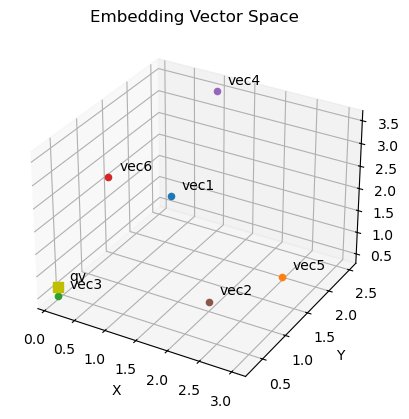

In [59]:
import matplotlib.pyplot as plt

# 3D 플롯을 생성합니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 각 벡터의 ID와 값을 사용하여 3D 공간에 점을 그립니다.
for i, id in enumerate(ids):
    if id == "qv":
        # 쿼리 벡터는 노란색 사각형으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id, color='y', s=50, marker='s')
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)
    else:
        # 나머지 벡터는 기본 색상으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id)
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)

# 축 레이블과 제목을 설정합니다.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embedding Vector Space')

# 플롯을 표시합니다.
plt.show()

# wiki index

In [103]:
index_name = 'wiki'

pc.create_index(
    name=index_name,
    dimension=1536,  # 모델 차원
    metric="cosine",  # 모델 메트릭
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

{
    "name": "wiki",
    "metric": "cosine",
    "host": "wiki-mnztm69.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 1536,
    "deletion_protection": "disabled",
    "tags": null
}

In [104]:
w_index = pc.Index(index_name)

In [105]:
w_index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [64]:
from datasets import load_dataset

data = load_dataset('wikimedia/wikipedia', '20231101.ko', split='train[:100]')
print(data)
print(data[0])

c:\Users\Admin\miniconda3\envs\langchain_rag_env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\datasets--wikimedia--wikipedia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 647897/647897 [00:01<00:00, 348941.61 examples/s]


Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 100
})
{'id': '5', 'url': 'https://ko.wikipedia.org/wiki/%EC%A7%80%EB%AF%B8%20%EC%B9%B4%ED%84%B0', 'title': '지미 카터', 'text': '제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.\n\n생애\n\n어린 시절 \n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.\n\n조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n\n정계 입문 \n1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n\n대통령 재임 \n\n1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.\n\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n\n외교 정책 \n카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.\n\n소련과 제2차 전략 무기 제한 

In [98]:
data[0]['text']

'제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.\n\n생애\n\n어린 시절 \n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.\n\n조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n\n정계 입문 \n1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n\n대통령 재임 \n\n1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.\n\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n\n외교 정책 \n카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.\n\n소련과 제2차 전략 무기 제한 협상(SALT II)에 조인했다.\n\n카터는 1970년대 후반 당시 대한민국 등 인권 후진국의 국민들의 인권을 지키기 위해 노력했으며, 취임 이후 계속해서 도덕정치를 내세웠다.\n\n임기 말, 소련의 아프가니스탄 침공 사건으로 인해 1980년 하계 올림픽에 반공국가들의 보이콧을 하였다.\n\n그는 주이란 미국 대사관 인질 사건의 인질 구출 실패로

In [ ]:
len(data[0]['text'])

3608

In [68]:
for record in data:
  if len(data[0]['text']) > 3500:
    print(record['id'], len(record['text']), record['title'])

5 3608 지미 카터
9 5087 수학
10 872 수학 상수
19 3340 문학
20 2790 나라 목록
21 8109 화학
22 3559 체첸 공화국
24 7023 맥스웰 방정식
26 4763 초월수
31 1027 음계
34 7361 대한민국 제16대 대통령 선거
36 8587 함석헌
38 11401 백남준
39 13555 2002년
40 2366 12월 19일
41 2534 5월 31일
42 3582 6월 30일
44 10135 우크라이나
48 1296 가위
49 3668 위키
57 1299 지구과학
62 2866 아오조라 문고
63 1539 프로젝트 구텐베르크
65 5203 겐지모노가타리
66 1674 귄터 그라스
70 4042 일반 상대성이론
73 1077 데니스 리치
76 4181 주기율표
77 17204 아미노산
78 942 히라가나
79 3129 나라 이름순 수도 목록
80 3961 토마스 만
82 2588 하인리히 뵐
83 1904 방정식
84 2361 삼각함수 항등식
85 72992 노무현
86 1430 곱셈적 함수
87 1037 체비쇼프 다항식
88 664 파이의 날
89 3460 코사인 법칙
90 1439 사인 법칙
91 4104 벡터 공간
92 540 펜로즈 삼각형
94 825 수론적 함수
95 571 물리 상수
96 3422 대수학의 기본 정리
97 1734 정규 분포
99 654 공각기동대
100 839 뫼비우스 반전 공식
101 1032 푸리에 급수
104 102 가수
111 1597 감마 함수
139 7234 아쿠타가와 류노스케
140 4660 장국영
141 11038 통계학
143 9873 컴퓨터 과학
145 11331 위키백과
149 160 그리스 신들의 가계도
150 1154 광자
151 1393 보손
152 1534 디리클레 합성곱
154 879 동치관계
155 4705 자연철학의 수학적 원리
156 1729 슈뢰딩거 방정식
158 3728 엔트로피
159 1606 라플라스 방정식
160 657 적분표
161 3349 삼

In [106]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# RecursiveCharacterTextSplitter를 초기화합니다.
# 이 클래스는 텍스트를 재귀적으로 문자 단위로 분할합니다.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,  # 분할할 텍스트의 크기
    #chunk_size=1000,  # 분할할 텍스트의 크기
    #chunk_size=2048,  # 분할할 텍스트의 크기
    #chunk_overlap=100,  # 분할된 텍스트의 중첩 크기
    chunk_overlap=20,  # 분할된 텍스트의 중첩 크기
    length_function=len,  # 텍스트 길이를 계산하는 함수
    separators=["\n\n", "\n", " ", ""]  # 분할할 텍스트의 구분자
)

splitter

In [107]:
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')

In [108]:
from tqdm.auto import tqdm
from uuid import uuid4
import time

batch_size = 20  #한 번에 올린 upsert 요청 바디가 3MB, Pinecone 서버의 2MB 제한을 넘으면 오류 > 배치사이즈 작게 하기
texts = []
metas = []
count = 0

# 데이터셋의 각 샘플에 대해 반복합니다.
for i, sample in enumerate(tqdm(data)):

    full_text = sample["text"] # Wikipedia 문서 텍스트
    metadata = {
        'wiki_id': str(sample["id"]),  # Wikipedia 문서 ID
        'url': sample["url"],  # Wikipedia 문서 URL
        'title': sample["title"],  # Wikipedia 문서 제목
    }

		# 텍스트를 청크로 분할합니다.
    chunks = splitter.split_text(full_text)  # 텍스트를 청크로 분할합니다.
    #print(len(chunks))

    # 각 청크에 대해 반복합니다.
    for i, chunk in enumerate(chunks):
        record = {
            'chunk_id': i,  # 청크 ID
            'full_text': full_text[:300],  # 전체 텍스트
            **metadata,  # 메타데이터 언패킹
        }

        texts.append(chunk)  # 청크를 텍스트 목록에 추가합니다.
        metas.append(record)  # 메타데이터를 메타데이터 목록에 추가합니다.

        count += 1  # 처리된 청크 수를 증가시킵니다.

        # batch_size만큼의 청크를 처리할 때마다 청크를 Pinecone 인덱스에 추가합니다.
        if count % batch_size == 0:
            # Pinecone 인덱스에 청크를 추가합니다.
            ids = [str(uuid4()) for _ in range(len(texts))]
            embeddings = embedding_model.embed_documents(texts)
            w_index.upsert(
                vectors=zip(ids, embeddings, metas),
                namespace="wiki-ns1")
            # 청크 목록과 메타데이터 목록을 비웁니다.
            texts = []
            metas = []
            # 1초 대기합니다.
            time.sleep(1)

100%|██████████| 100/100 [03:53<00:00,  2.33s/it]


In [113]:
from langchain_pinecone import PineconeVectorStore
vectorstore = PineconeVectorStore.from_existing_index(
  index_name='wiki',
  embedding=embedding_model,
  text_key='full_text',
  namespace='wiki-ns1'
)

In [114]:
results = vectorstore.similarity_search(
  query='대한민국의 수도는 어디인가요?',
  k=3,
  namespace='wiki-ns1'
)
print(f'결과 수 :{len(results)}')
for i, r in enumerate(results):
  print(f'\n[ {i+1}]')
  print(f'page_content: {r.page_content[:100]}')
  print(f'metadata: {r.metadata}')

결과 수 :3

[ 1]
page_content: 국

ㄱ 

 가나 - 아크라 
 가봉 - 리브르빌
 가이아나 - 조지타운
 감비아 - 반줄
 괌 - 하갓냐
 과테말라 - 과테말라
 그레나다 - 세인트조지스
 그리스 - 아테네

metadata: {'chunk_id': 10.0, 'title': '나라 이름순 수도 목록', 'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EC%9D%B4%EB%A6%84%EC%88%9C%20%EC%88%98%EB%8F%84%20%EB%AA%A9%EB%A1%9D', 'wiki_id': '79'}

[ 2]
page_content: 노무현(盧武鉉, 1946년 9월 1일~2009년 5월 23일)은 대한민국의 제16대 대통령이다. 판사로 재직 후 부산에서 변호사로 활동하다가 제13·15대 국회의원직을 역임했고, 
metadata: {'chunk_id': 88.0, 'title': '노무현', 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}

[ 3]
page_content: 노무현(盧武鉉, 1946년 9월 1일~2009년 5월 23일)은 대한민국의 제16대 대통령이다. 판사로 재직 후 부산에서 변호사로 활동하다가 제13·15대 국회의원직을 역임했고, 
metadata: {'chunk_id': 8.0, 'title': '노무현', 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}


In [115]:
retriever = vectorstore.as_retriever(search_kwargs={'k':3,'namespace':'wiki-ns1'})

# 한국어 위키 기반 검색 테스트
queries = [
  '대한민국의 수도는 어디인가요?',
  '삼성전자는 어떤 회사인가요?',
  '한국의 전통 음식은 무엇인가요?'
]

In [116]:
for query in queries:
  print(f'[질문]{query}')
  results = retriever.invoke(query)
  for i, r in enumerate(results):
    print(f' {i+1}.[{r.metadata.get('title')}]{r.page_content[:80]}')
  print()

[질문]대한민국의 수도는 어디인가요?
 1.[나라 이름순 수도 목록]국

ㄱ 

 가나 - 아크라 
 가봉 - 리브르빌
 가이아나 - 조지타운
 감비아 - 반줄
 괌 - 하갓냐
 과테말라 - 과테말라
 그레나다 
 2.[노무현]노무현(盧武鉉, 1946년 9월 1일~2009년 5월 23일)은 대한민국의 제16대 대통령이다. 판사로 재직 후 부산에서 변호사로 활동하다가 제
 3.[노무현]노무현(盧武鉉, 1946년 9월 1일~2009년 5월 23일)은 대한민국의 제16대 대통령이다. 판사로 재직 후 부산에서 변호사로 활동하다가 제

[질문]삼성전자는 어떤 회사인가요?
 1.[구글]구글()은 구글 검색을 중심으로 스마트폰 운영체제인 안드로이드와 유튜브 사업, 클라우드 사업을 하는 미국의 기업이다. 다양한 구글 서비스들(메일
 2.[구글]구글()은 구글 검색을 중심으로 스마트폰 운영체제인 안드로이드와 유튜브 사업, 클라우드 사업을 하는 미국의 기업이다. 다양한 구글 서비스들(메일
 3.[노무현]노무현(盧武鉉, 1946년 9월 1일~2009년 5월 23일)은 대한민국의 제16대 대통령이다. 판사로 재직 후 부산에서 변호사로 활동하다가 제

[질문]한국의 전통 음식은 무엇인가요?
 1.[우크라이나]우크라이나()는 동유럽 국가다. 남쪽과 남동쪽으로는 흑해와 아조프해, 동쪽과 북동쪽으로는 러시아, 북쪽과 북서쪽으로는 벨라루스, 서쪽으로는 폴란
 2.[음계]음계(音階)는 음악에서 음높이(pitch) 순서로 된 음의 집합을 말한다. 악곡을 주로 구성하는 음을 나타낸 것이며 음계의 종류에 따라 곡의 분
 3.[표준 모형]소립자 물리학의 표준 모형(標準模型, )은 자연계의 기본 입자와, 중력을 제외한 그 상호작용 (강한 상호작용, 약한 상호작용, 전자기 상호작용)

